In [1]:
#Import thư viện
import kagglehub
import pandas as pd
import os
import re
import numpy as np
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
#Tải dataset IMDB 50k reviews
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Dataset đã được tải về tại:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset đã được tải về tại: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [3]:
# Path tới folder dataset trên Colab
dataset_folder = "/kaggle/input/imdb-dataset-of-50k-movie-reviews"

# Kiểm tra các file bên trong
print("Các file trong folder:", os.listdir(dataset_folder))

# Đọc CSV trực tiếp
data_path = os.path.join(dataset_folder, "IMDB Dataset.csv")
data = pd.read_csv(data_path)

# Hiển thị dữ liệu
print(data.head())


Các file trong folder: ['IMDB Dataset.csv']
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [4]:
# Hàm tiền xử lý nhanh
def preprocess_fast(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)        # xóa HTML
    text = re.sub(r'[^a-z\s]', ' ', text)    # xóa ký tự đặc biệt/số
    text = re.sub(r'\s+', ' ', text)         # gộp khoảng trắng
    text = re.sub(r'\bnot\s+(\w+)\b', r'not_\1', text) # not good -> not_good
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return ' '.join(words)

In [5]:
data['clean_review'] = data['review'].apply(preprocess_fast)

In [6]:
data['clean_review']

,clean_review
0,reviewers mentioned watching just oz episode l...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically s family little boy jake thinks s zo...
4,petter mattei s love time money visually stunn...
...,...
49995,thought movie did right good job wasn t creati...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,catholic taught parochial elementary schools n...
49998,m going disagree previous comment maltin secon...


In [7]:
X = data['clean_review']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
tfidf = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1,3))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [9]:
# -------------------------------
# Decision Tree Node & Gini
# -------------------------------
class DecisionTreeNode:
    def __init__(self, depth=0, max_depth=None):
        self.left = None
        self.right = None
        self.feature_index = None
        self.threshold = None
        self.prediction = None
        self.depth = depth
        self.max_depth = max_depth

def gini(y):
    classes = np.unique(y)
    gini_score = 1.0
    for c in classes:
        p = np.sum(y == c) / len(y)
        gini_score -= p**2
    return gini_score

def best_split(X, y, feature_indices):
    best_gini = 1.0
    best_idx = None
    best_thr = None
    for idx in feature_indices:
        thresholds = np.unique(X[:, idx])
        for thr in thresholds:
            left_mask = X[:, idx] <= thr
            right_mask = X[:, idx] > thr
            if len(y[left_mask]) == 0 or len(y[right_mask]) == 0:
                continue
            gini_left = gini(y[left_mask])
            gini_right = gini(y[right_mask])
            gini_total = (len(y[left_mask])*gini_left + len(y[right_mask])*gini_right)/len(y)
            if gini_total < best_gini:
                best_gini = gini_total
                best_idx = idx
                best_thr = thr
    return best_idx, best_thr

In [10]:
# -------------------------------
# Build Decision Tree
# -------------------------------
def build_tree(X, y, depth=0, max_depth=5, n_features=None):
    node = DecisionTreeNode(depth=depth, max_depth=max_depth)

    # Stop condition
    if depth == max_depth or len(np.unique(y)) == 1:
        counts = np.bincount(y)
        node.prediction = np.argmax(counts)
        return node

    n_samples, n_feats = X.shape
    if n_features is None:
        n_features = int(np.sqrt(n_feats))

    feature_indices = np.random.choice(n_feats, n_features, replace=False)
    feature_index, threshold = best_split(X, y, feature_indices)

    if feature_index is None:
        counts = np.bincount(y)
        node.prediction = np.argmax(counts)
        return node

    node.feature_index = feature_index
    node.threshold = threshold

    left_mask = X[:, feature_index] <= threshold
    right_mask = X[:, feature_index] > threshold

    node.left = build_tree(X[left_mask], y[left_mask], depth+1, max_depth=max_depth, n_features=n_features)
    node.right = build_tree(X[right_mask], y[right_mask], depth+1, max_depth=max_depth, n_features=n_features)

    return node

In [11]:
# -------------------------------
# Predict single sample
# -------------------------------
def tree_predict(node, x):
    if node.prediction is not None:
        return node.prediction
    if x[node.feature_index] <= node.threshold:
        return tree_predict(node.left, x)
    else:
        return tree_predict(node.right, x)

In [12]:
# -------------------------------
# Random Forest
# -------------------------------
class RandomForest:
    def __init__(self, n_trees=5, max_depth=5, n_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.n_features = n_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]
        for _ in range(self.n_trees):
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            X_sample = X[idxs]
            y_sample = y[idxs]
            tree = build_tree(X_sample, y_sample, max_depth=self.max_depth, n_features=self.n_features)
            self.trees.append(tree)

    def predict(self, X):
        y_pred = []
        for x in X:
            votes = [tree_predict(tree, x) for tree in self.trees]
            y_pred.append(np.bincount(votes).argmax())
        return np.array(y_pred)

In [13]:
# Giả sử y_train, y_test là series với 'positive' / 'negative'
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # 'negative' -> 0, 'positive' -> 1
y_test_encoded = le.transform(y_test)

In [14]:
X_train_small = X_train_tfidf[:5000].toarray()
y_train_small_encoded = y_train_encoded[:5000]
X_test_small = X_test_tfidf[:10000].toarray()
y_test_small_encoded = y_test_encoded[:10000]

In [15]:
rf = RandomForest(n_trees=50, max_depth = 30, n_features=50)

In [16]:
rf.fit(X_train_small, y_train_small_encoded)

In [17]:
y_pred = rf.predict(X_test_small)

In [18]:
print("Accuracy:", round(accuracy_score(y_test_small_encoded, y_pred), 4))
print(classification_report(y_test_small_encoded, y_pred, target_names=le.classes_))

Accuracy: 0.7595
              precision    recall  f1-score   support

    negative       0.91      0.57      0.70      4961
    positive       0.69      0.94      0.80      5039

    accuracy                           0.76     10000
   macro avg       0.80      0.76      0.75     10000
weighted avg       0.80      0.76      0.75     10000



In [19]:
print(confusion_matrix(y_test_small_encoded, y_pred))

[[2835 2126]
 [ 279 4760]]


In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
y_test_labels = np.where(y_test_small_encoded == 0, "negative", "positive")
y_pred_labels = np.where(y_pred == 0, "negative", "positive")

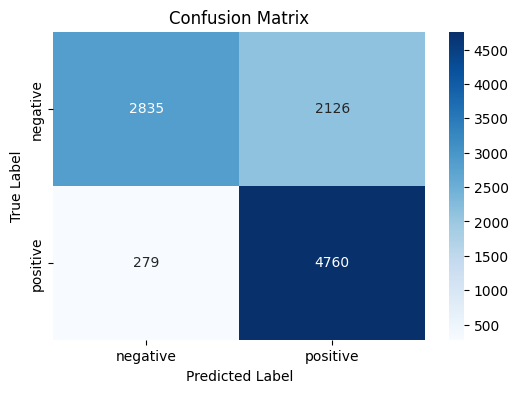

In [22]:
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=["negative", "positive"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

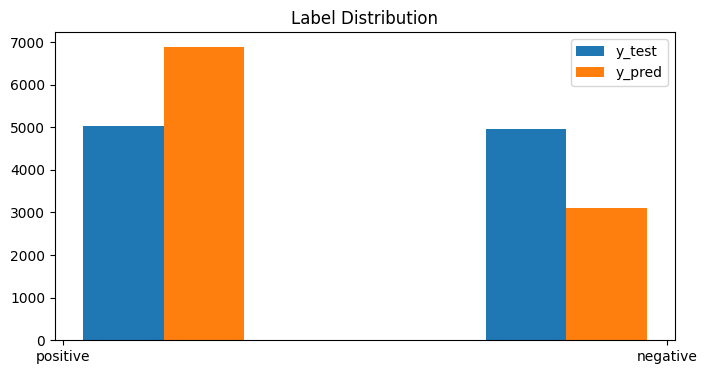

In [23]:
plt.figure(figsize=(8,4))
plt.hist([y_test_labels, y_pred_labels], bins=3, label=["y_test", "y_pred"])
plt.legend()
plt.title("Label Distribution")
plt.show()

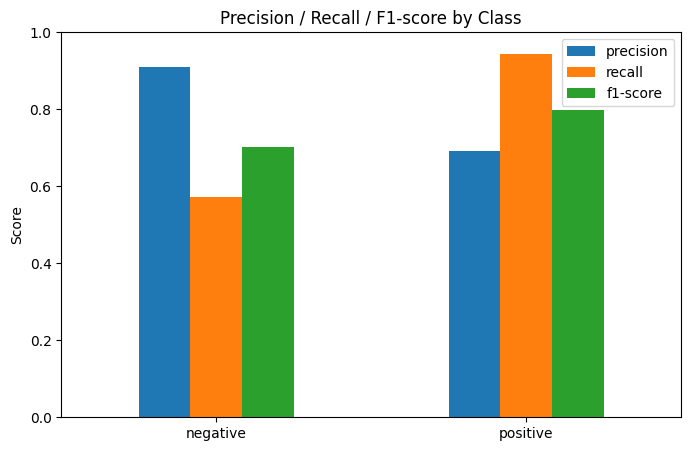

In [24]:
report = classification_report(y_test_labels, y_pred_labels, output_dict=True)
df = pd.DataFrame(report).transpose().iloc[:2, :3]   # chỉ lấy 2 class
df.plot(kind='bar', figsize=(8,5))
plt.title("Precision / Recall / F1-score by Class")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()